In [7]:
# Loading data fully for the experiments

import numpy as np
import pandas as pd
import torch

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# ============================================================
# Paths
# ============================================================

RAW_DATA_DIR = Path("../data/raw")

TRAIN_PATH = RAW_DATA_DIR / "train_FD001.txt"
TEST_PATH = RAW_DATA_DIR / "test_FD001.txt"
TEST_RUL_PATH = RAW_DATA_DIR / "RUL_FD001.txt"


# ============================================================
# Column names
# ============================================================

column_names = (
    ["engine_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)


# ============================================================
# Load raw data
# ============================================================

train_full = pd.read_csv(
    TRAIN_PATH,
    sep=r"\s+",
    header=None,
    names=column_names,
)

test_df = pd.read_csv(
    TEST_PATH,
    sep=r"\s+",
    header=None,
    names=column_names,
)

rul_test = pd.read_csv(
    TEST_RUL_PATH,
    sep=r"\s+",
    header=None,
    names=["rul"],
)


# ============================================================
# Create RUL target for training data
# ============================================================

engine_lifetimes = (
    train_full
    .groupby("engine_id")["cycle"]
    .max()
)

train_full["max_cycle"] = (
    train_full["engine_id"]
    .map(engine_lifetimes)
)

train_full["rul"] = (
    train_full["max_cycle"]
    - train_full["cycle"]
)


# ============================================================
# Capped RUL target
# ============================================================

RUL_CAP = 125

train_full["rul_capped"] = (
    train_full["rul"]
    .clip(upper=RUL_CAP)
)


# ============================================================
# Remove constant columns
# ============================================================

constant_columns = (
    train_full
    .nunique()
    .loc[lambda x: x == 1]
    .index
    .tolist()
)

train_full = (
    train_full
    .drop(columns=constant_columns)
    .copy()
)

test_df = (
    test_df
    .drop(columns=constant_columns)
    .copy()
)


# ============================================================
# Same engine-level train / validation split
# ============================================================

engine_ids = train_full["engine_id"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42,
)

train_df = train_full[
    train_full["engine_id"].isin(train_engines)
].copy()

val_df = train_full[
    train_full["engine_id"].isin(val_engines)
].copy()


# ============================================================
# Sequence feature columns
# ============================================================

sequence_feature_columns = [
    col
    for col in train_df.columns
    if col not in [
        "engine_id",
        "max_cycle",
        "rul",
        "rul_capped",
    ]
]


print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print()
print("Train engines:", len(train_engines))
print("Validation engines:", len(val_engines))

print()
print("Sequence features:")
print(sequence_feature_columns)

print()
print("Constant columns removed:")
print(constant_columns)

Train shape: (16561, 22)
Validation shape: (4070, 22)
Test shape: (13096, 19)

Train engines: 80
Validation engines: 20

Sequence features:
['cycle', 'setting_1', 'setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']

Constant columns removed:
['setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


,engine_id,cycle,setting_1,setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_cycle,rul,rul_capped
192,2,1,-0.0018,0.0006,641.89,1583.84,1391.28,21.60,554.53,2388.01,...,522.33,2388.06,8137.72,8.3905,391,38.94,23.4585,287,286,125
193,2,2,0.0043,-0.0003,641.82,1587.05,1393.13,21.61,554.77,2387.98,...,522.70,2387.98,8131.09,8.4167,392,39.06,23.4085,287,285,125
194,2,3,0.0018,0.0003,641.55,1588.32,1398.96,21.60,555.14,2388.04,...,522.58,2387.99,8140.58,8.3802,391,39.11,23.4250,287,284,125
195,2,4,0.0035,-0.0004,641.68,1584.15,1396.08,21.61,554.25,2387.98,...,522.49,2387.93,8140.44,8.4018,391,39.13,23.5027,287,283,125
196,2,5,0.0005,0.0004,641.73,1579.03,1402.52,21.60,555.12,2388.03,...,522.27,2387.94,8136.67,8.3867,390,39.18,23.4234,287,282,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,...,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,200,4,4
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,...,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,200,3,3
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,...,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,200,2,2
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,...,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,200,1,1


In [3]:
train_engines

array([ 56,  89,  27,  43,  70,  16,  41,  97,  10,  73,  12,  48,  86,
        29,  94,   6,  67,  66,  36,  17,  50,  35,   8,  96,  28,  20,
        82,  26,  63,  14,  25,   4,  18,  39,   9,  79,   7,  65,  37,
        90,  57, 100,  55,  44,  51,  68,  47,  69,  62,  98,  80,  42,
        59,  49,  99,  58,  76,  33,  95,  60,  64,  85,  38,  30,   2,
        53,  22,   3,  24,  88,  92,  75,  87,  83,  21,  61,  72,  15,
        93,  52])

In [5]:
import copy
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from torch.utils.data import TensorDataset, DataLoader


# ============================================================
# 1. Create overlapping sequences
# ============================================================

def create_sequences(
    df,
    feature_columns,
    target_column="rul_capped",
    window=30,
):
    """
    Convert engine trajectories into overlapping fixed-length sequences.

    Example with window=30:

        cycles 1-30  -> target at cycle 30
        cycles 2-31  -> target at cycle 31
        cycles 3-32  -> target at cycle 32
        ...

    Returns
    -------
    X : np.ndarray
        Shape:
        (number_of_sequences, window, number_of_features)

    y : np.ndarray
        Shape:
        (number_of_sequences,)
    """
    X = []
    y = []

    for engine_id, engine_data in df.groupby("engine_id"):

        engine_data = engine_data.sort_values("cycle")

        features = (
            engine_data[feature_columns]
            .to_numpy()
        )

        targets = (
            engine_data[target_column]
            .to_numpy()
        )

        for end_idx in range(
            window - 1,
            len(engine_data),
        ):

            start_idx = (
                end_idx
                - window
                + 1
            )

            sequence = features[
                start_idx:end_idx + 1
            ]

            target = targets[end_idx]

            X.append(sequence)
            y.append(target)

    return (
        np.array(X),
        np.array(y),
    )


# ============================================================
# 2. Scale sequence data
# ============================================================

def scale_sequences(
    X_train,
    X_val,
):
    """
    Standardize each feature using training data only.

    The sequence tensors are temporarily reshaped from:

        (samples, timesteps, features)

    into:

        (samples * timesteps, features)

    so StandardScaler can scale each feature independently.

    Returns
    -------
    X_train_scaled
    X_val_scaled
    scaler
    """
    scaler = StandardScaler()

    n_train, timesteps, n_features = (
        X_train.shape
    )

    n_val = X_val.shape[0]

    # Flatten temporal dimension temporarily.
    X_train_2d = X_train.reshape(
        -1,
        n_features,
    )

    X_val_2d = X_val.reshape(
        -1,
        n_features,
    )

    # Fit only on training data.
    X_train_scaled_2d = (
        scaler.fit_transform(
            X_train_2d
        )
    )

    X_val_scaled_2d = (
        scaler.transform(
            X_val_2d
        )
    )

    # Restore sequence shape.
    X_train_scaled = (
        X_train_scaled_2d.reshape(
            n_train,
            timesteps,
            n_features,
        )
    )

    X_val_scaled = (
        X_val_scaled_2d.reshape(
            n_val,
            timesteps,
            n_features,
        )
    )

    return (
        X_train_scaled,
        X_val_scaled,
        scaler,
    )


# ============================================================
# 3. LSTM model
# ============================================================

class RULPredictor(nn.Module):
    """
    LSTM-based Remaining Useful Life predictor.
    """

    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=1,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )

        self.output_layer = nn.Linear(
            hidden_size,
            1,
        )

    def forward(self, x):
        """
        Predict one RUL value per input sequence.
        """
        lstm_output, _ = self.lstm(x)

        # Representation after final timestep.
        final_hidden = (
            lstm_output[:, -1, :]
        )

        prediction = (
            self.output_layer(
                final_hidden
            )
        )

        return prediction.squeeze(1)


# ============================================================
# 4. Asymmetric loss
# ============================================================

def asymmetric_mse(
    predictions,
    targets,
    overprediction_weight=2.0,
):
    """
    Penalize RUL overprediction more heavily.

    Positive error means:

        prediction > target

    which means the model thinks the engine has more
    remaining life than it actually has.
    """
    errors = (
        predictions
        - targets
    )

    weights = torch.where(
        errors > 0,
        torch.full_like(
            errors,
            overprediction_weight,
        ),
        torch.ones_like(errors),
    )

    return torch.mean(
        weights
        * errors.pow(2)
    )


# ============================================================
# 5. Create DataLoaders
# ============================================================

def create_loaders(
    X_train,
    y_train,
    X_val,
    y_val,
    batch_size=64,
):
    """
    Convert NumPy arrays to PyTorch tensors and DataLoaders.
    """
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32,
    )

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.float32,
    )

    X_val_tensor = torch.tensor(
        X_val,
        dtype=torch.float32,
    )

    y_val_tensor = torch.tensor(
        y_val,
        dtype=torch.float32,
    )

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor,
    )

    val_dataset = TensorDataset(
        X_val_tensor,
        y_val_tensor,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    return (
        train_loader,
        val_loader,
        X_val_tensor,
        y_val_tensor,
    )


# ============================================================
# 6. Train model and keep best validation checkpoint
# ============================================================

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=30,
    learning_rate=0.001,
    overprediction_weight=2.0,
):
    """
    Train an LSTM using asymmetric MSE.

    The best model is chosen using validation loss.
    """
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    best_val_loss = float("inf")
    best_model_state = None
    best_epoch = None

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        train_loss = 0.0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            predictions = model(
                X_batch
            )

            loss = asymmetric_mse(
                predictions,
                y_batch,
                overprediction_weight=(
                    overprediction_weight
                ),
            )

            loss.backward()

            optimizer.step()

            train_loss += (
                loss.item()
                * X_batch.size(0)
            )

        train_loss /= len(
            train_loader.dataset
        )

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                predictions = model(
                    X_batch
                )

                loss = asymmetric_mse(
                    predictions,
                    y_batch,
                    overprediction_weight=(
                        overprediction_weight
                    ),
                )

                val_loss += (
                    loss.item()
                    * X_batch.size(0)
                )

        val_loss /= len(
            val_loader.dataset
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        # Save best checkpoint.
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            best_epoch = epoch + 1

            best_model_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

        print(
            f"Epoch {epoch + 1:02d} | "
            f"Train Loss: {train_loss:.2f} | "
            f"Val Loss: {val_loss:.2f}"
        )

    # Restore best checkpoint.
    model.load_state_dict(
        best_model_state
    )

    return (
        model,
        history,
        best_epoch,
        best_val_loss,
    )


# ============================================================
# 7. Evaluate model
# ============================================================

def evaluate_model(
    model,
    X_tensor,
    y_true,
):
    """
    Calculate predictions, MAE, MSE, and RMSE.
    """
    model.eval()

    with torch.no_grad():

        predictions = (
            model(X_tensor)
            .cpu()
            .numpy()
        )

    mae = mean_absolute_error(
        y_true,
        predictions,
    )

    mse = mean_squared_error(
        y_true,
        predictions,
    )

    rmse = np.sqrt(mse)

    return {
        "predictions": predictions,
        "mae": mae,
        "mse": mse,
        "rmse": rmse,
    }

In [6]:
# ============================================================
# Experiment A: Full 30-cycle sequence
# ============================================================

WINDOW = 30

# Create overlapping sequences.
X_train_full, y_train_full = create_sequences(
    train_df,
    feature_columns=sequence_feature_columns,
    target_column="rul_capped",
    window=WINDOW,
)

X_val_full, y_val_full = create_sequences(
    val_df,
    feature_columns=sequence_feature_columns,
    target_column="rul_capped",
    window=WINDOW,
)

print("Before scaling")
print("X_train:", X_train_full.shape)
print("X_val:", X_val_full.shape)


# Scale using training data only.
X_train_full_scaled, X_val_full_scaled, full_scaler = (
    scale_sequences(
        X_train_full,
        X_val_full,
    )
)


# Create PyTorch loaders.
(
    train_loader_full,
    val_loader_full,
    X_val_full_tensor,
    y_val_full_tensor,
) = create_loaders(
    X_train_full_scaled,
    y_train_full,
    X_val_full_scaled,
    y_val_full,
    batch_size=64,
)


# Create a fresh model.
model_full = RULPredictor(
    input_size=X_train_full_scaled.shape[2],
    hidden_size=64,
    num_layers=1,
)


# Train.
(
    model_full,
    history_full,
    best_epoch_full,
    best_val_loss_full,
) = train_model(
    model_full,
    train_loader_full,
    val_loader_full,
    epochs=30,
    learning_rate=0.001,
    overprediction_weight=2.0,
)


# Evaluate the best checkpoint.
results_full = evaluate_model(
    model_full,
    X_val_full_tensor,
    y_val_full,
)


print()
print("Full sequence baseline")
print(f"Best epoch: {best_epoch_full}")
print(f"Validation MAE:  {results_full['mae']:.2f}")
print(f"Validation MSE:  {results_full['mse']:.2f}")
print(f"Validation RMSE: {results_full['rmse']:.2f}")

Before scaling
X_train: (14241, 30, 18)
X_val: (3490, 30, 18)
Epoch 01 | Train Loss: 6721.76 | Val Loss: 5412.67
Epoch 02 | Train Loss: 4719.34 | Val Loss: 3905.96
Epoch 03 | Train Loss: 3429.12 | Val Loss: 2838.64
Epoch 04 | Train Loss: 2508.46 | Val Loss: 2082.76
Epoch 05 | Train Loss: 1851.55 | Val Loss: 1554.33
Epoch 06 | Train Loss: 1373.25 | Val Loss: 1131.68
Epoch 07 | Train Loss: 1022.22 | Val Loss: 842.22
Epoch 08 | Train Loss: 767.03 | Val Loss: 640.03
Epoch 09 | Train Loss: 585.29 | Val Loss: 488.12
Epoch 10 | Train Loss: 453.53 | Val Loss: 394.25
Epoch 11 | Train Loss: 362.89 | Val Loss: 333.64
Epoch 12 | Train Loss: 294.41 | Val Loss: 286.35
Epoch 13 | Train Loss: 251.88 | Val Loss: 263.40
Epoch 14 | Train Loss: 212.53 | Val Loss: 285.98
Epoch 15 | Train Loss: 189.31 | Val Loss: 250.65
Epoch 16 | Train Loss: 159.96 | Val Loss: 259.23
Epoch 17 | Train Loss: 144.98 | Val Loss: 253.85
Epoch 18 | Train Loss: 134.54 | Val Loss: 283.20
Epoch 19 | Train Loss: 111.52 | Val Loss: 3

### Is the final timestamp(latest snapshot of senesors) enough or we really need 30-cycle history?

In [10]:
# ============================================================
# Experiment B: Final timestep only
# ============================================================

# Take only the last timestep from each 30-cycle sequence.
# Keep a sequence dimension of length 1 so the same LSTM model can be used.
X_train_last = X_train_full_scaled[:, -1:, :]
X_val_last = X_val_full_scaled[:, -1:, :]

print("Experiment B: Final timestep only")
print("X_train:", X_train_last.shape)
print("X_val:", X_val_last.shape)


# Create PyTorch loaders.
(
    train_loader_last,
    val_loader_last,
    X_val_last_tensor,
    y_val_last_tensor,
) = create_loaders(
    X_train_last,
    y_train_full,
    X_val_last,
    y_val_full,
    batch_size=64,
)


# Fresh model.
model_last = RULPredictor(
    input_size=X_train_last.shape[2],
    hidden_size=64,
    num_layers=1,
)


# Train.
(
    model_last,
    history_last,
    best_epoch_last,
    best_val_loss_last,
) = train_model(
    model_last,
    train_loader_last,
    val_loader_last,
    epochs=60,
    learning_rate=0.001,
    overprediction_weight=2.0,
)


# Evaluate.
results_last = evaluate_model(
    model_last,
    X_val_last_tensor,
    y_val_full,
)


print()
print("Experiment B: Final timestep only")
print(f"Best epoch: {best_epoch_last}")
print(
    f"Experiment B - Final timestep only - "
    f"Validation MAE: {results_last['mae']:.2f}"
)
print(
    f"Experiment B - Final timestep only - "
    f"Validation MSE: {results_last['mse']:.2f}"
)
print(
    f"Experiment B - Final timestep only - "
    f"Validation RMSE: {results_last['rmse']:.2f}"
)

Experiment B: Final timestep only
X_train: (14241, 1, 18)
X_val: (3490, 1, 18)
Epoch 01 | Train Loss: 7760.49 | Val Loss: 6810.40
Epoch 02 | Train Loss: 6141.14 | Val Loss: 5258.04
Epoch 03 | Train Loss: 4590.46 | Val Loss: 3707.45
Epoch 04 | Train Loss: 3205.01 | Val Loss: 2530.64
Epoch 05 | Train Loss: 2201.79 | Val Loss: 1743.23
Epoch 06 | Train Loss: 1552.29 | Val Loss: 1264.55
Epoch 07 | Train Loss: 1169.53 | Val Loss: 971.44
Epoch 08 | Train Loss: 934.08 | Val Loss: 782.04
Epoch 09 | Train Loss: 784.79 | Val Loss: 661.23
Epoch 10 | Train Loss: 690.43 | Val Loss: 583.00
Epoch 11 | Train Loss: 631.39 | Val Loss: 531.65
Epoch 12 | Train Loss: 594.45 | Val Loss: 498.39
Epoch 13 | Train Loss: 570.87 | Val Loss: 474.55
Epoch 14 | Train Loss: 555.30 | Val Loss: 457.15
Epoch 15 | Train Loss: 543.79 | Val Loss: 442.64
Epoch 16 | Train Loss: 535.08 | Val Loss: 430.82
Epoch 17 | Train Loss: 527.38 | Val Loss: 420.21
Epoch 18 | Train Loss: 520.46 | Val Loss: 410.49
Epoch 19 | Train Loss: 513

### Removing "cycle" feature to check the causes/performance

In [11]:
# ============================================================
# Experiment C: Full 30-cycle sequence WITHOUT cycle feature
# ============================================================

sequence_feature_columns_no_cycle = [
    col
    for col in sequence_feature_columns
    if col != "cycle"
]

print("Experiment C: No cycle feature")
print(
    "Number of features:",
    len(sequence_feature_columns_no_cycle),
)


# Create sequences without cycle.
X_train_no_cycle, y_train_no_cycle = create_sequences(
    train_df,
    feature_columns=sequence_feature_columns_no_cycle,
    target_column="rul_capped",
    window=WINDOW,
)

X_val_no_cycle, y_val_no_cycle = create_sequences(
    val_df,
    feature_columns=sequence_feature_columns_no_cycle,
    target_column="rul_capped",
    window=WINDOW,
)

print("Before scaling")
print("X_train:", X_train_no_cycle.shape)
print("X_val:", X_val_no_cycle.shape)


# Scale using training data only.
(
    X_train_no_cycle_scaled,
    X_val_no_cycle_scaled,
    no_cycle_scaler,
) = scale_sequences(
    X_train_no_cycle,
    X_val_no_cycle,
)


# Create loaders.
(
    train_loader_no_cycle,
    val_loader_no_cycle,
    X_val_no_cycle_tensor,
    y_val_no_cycle_tensor,
) = create_loaders(
    X_train_no_cycle_scaled,
    y_train_no_cycle,
    X_val_no_cycle_scaled,
    y_val_no_cycle,
    batch_size=64,
)


# Fresh model.
model_no_cycle = RULPredictor(
    input_size=X_train_no_cycle_scaled.shape[2],
    hidden_size=64,
    num_layers=1,
)


# Train.
(
    model_no_cycle,
    history_no_cycle,
    best_epoch_no_cycle,
    best_val_loss_no_cycle,
) = train_model(
    model_no_cycle,
    train_loader_no_cycle,
    val_loader_no_cycle,
    epochs=30,
    learning_rate=0.001,
    overprediction_weight=2.0,
)


# Evaluate.
results_no_cycle = evaluate_model(
    model_no_cycle,
    X_val_no_cycle_tensor,
    y_val_no_cycle,
)


print()
print("Experiment C: No cycle feature")
print(f"Best epoch: {best_epoch_no_cycle}")

print(
    f"Experiment C - No cycle feature - "
    f"Validation MAE: {results_no_cycle['mae']:.2f}"
)

print(
    f"Experiment C - No cycle feature - "
    f"Validation MSE: {results_no_cycle['mse']:.2f}"
)

print(
    f"Experiment C - No cycle feature - "
    f"Validation RMSE: {results_no_cycle['rmse']:.2f}"
)

Experiment C: No cycle feature
Number of features: 17
Before scaling
X_train: (14241, 30, 17)
X_val: (3490, 30, 17)
Epoch 01 | Train Loss: 6672.70 | Val Loss: 5372.62
Epoch 02 | Train Loss: 4690.62 | Val Loss: 3882.93
Epoch 03 | Train Loss: 3411.44 | Val Loss: 2820.23
Epoch 04 | Train Loss: 2493.83 | Val Loss: 2060.59
Epoch 05 | Train Loss: 1832.02 | Val Loss: 1509.83
Epoch 06 | Train Loss: 1360.42 | Val Loss: 1131.68
Epoch 07 | Train Loss: 1038.12 | Val Loss: 863.75
Epoch 08 | Train Loss: 807.02 | Val Loss: 675.00
Epoch 09 | Train Loss: 642.97 | Val Loss: 517.51
Epoch 10 | Train Loss: 507.59 | Val Loss: 417.12
Epoch 11 | Train Loss: 416.21 | Val Loss: 349.48
Epoch 12 | Train Loss: 343.11 | Val Loss: 337.86
Epoch 13 | Train Loss: 309.75 | Val Loss: 302.18
Epoch 14 | Train Loss: 262.94 | Val Loss: 274.51
Epoch 15 | Train Loss: 230.75 | Val Loss: 231.58
Epoch 16 | Train Loss: 204.97 | Val Loss: 250.86
Epoch 17 | Train Loss: 187.34 | Val Loss: 268.28
Epoch 18 | Train Loss: 169.99 | Val Lo

In [12]:
import matplotlib.pyplot as plt
import numpy as np


def plot_actual_vs_predicted(
    y_true,
    predictions,
    experiment_name,
):
    """
    Scatter plot comparing actual and predicted RUL.

    The dashed diagonal represents perfect predictions:
        predicted RUL = actual RUL
    """
    y_true = np.asarray(y_true)
    predictions = np.asarray(predictions)

    # Use the same physical scale on both axes.
    lower_limit = min(
        y_true.min(),
        predictions.min(),
        0,
    )

    upper_limit = max(
        y_true.max(),
        predictions.max(),
        RUL_CAP,
    )

    plt.figure(figsize=(7, 7))

    plt.scatter(
        y_true,
        predictions,
        alpha=0.5,
    )

    # Perfect-prediction line.
    plt.plot(
        [lower_limit, upper_limit],
        [lower_limit, upper_limit],
        linestyle="--",
    )

    plt.xlim(lower_limit, upper_limit)
    plt.ylim(lower_limit, upper_limit)

    # Ensures one unit on x-axis has the same physical
    # length as one unit on y-axis.
    plt.axis("equal")

    plt.xlabel("Actual capped RUL")
    plt.ylabel("Predicted RUL")

    plt.title(
        f"{experiment_name}\n"
        "Actual vs Predicted RUL"
    )

    plt.grid(alpha=0.3)
    plt.show()

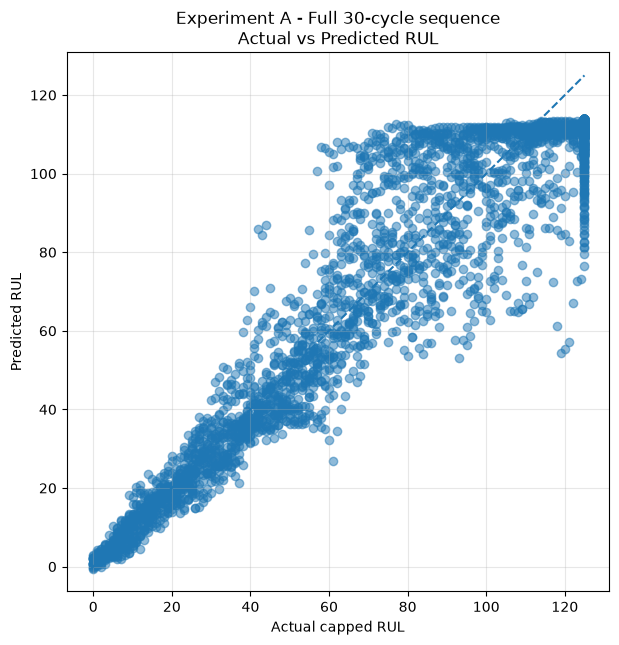

In [13]:
plot_actual_vs_predicted(
    y_val_full,
    results_full["predictions"],
    "Experiment A - Full 30-cycle sequence",
)

In [14]:
def plot_prediction_error(
    y_true,
    predictions,
    experiment_name,
):
    """
    Plot prediction error against actual capped RUL.

    Error = predicted RUL - actual RUL

    Positive error:
        model overpredicts remaining life

    Negative error:
        model underpredicts remaining life
    """
    error = predictions - y_true

    plt.figure(figsize=(8, 5))

    plt.scatter(
        y_true,
        error,
        alpha=0.6,
    )

    plt.axhline(
        y=0,
        linestyle="--",
    )

    plt.xlabel("Actual capped RUL")
    plt.ylabel("Prediction error (predicted - actual)")

    plt.title(
        f"{experiment_name}\n"
        "Prediction Error vs Actual RUL"
    )

    plt.ylim(-60, 60)
    plt.grid(alpha=0.3)

    plt.show()

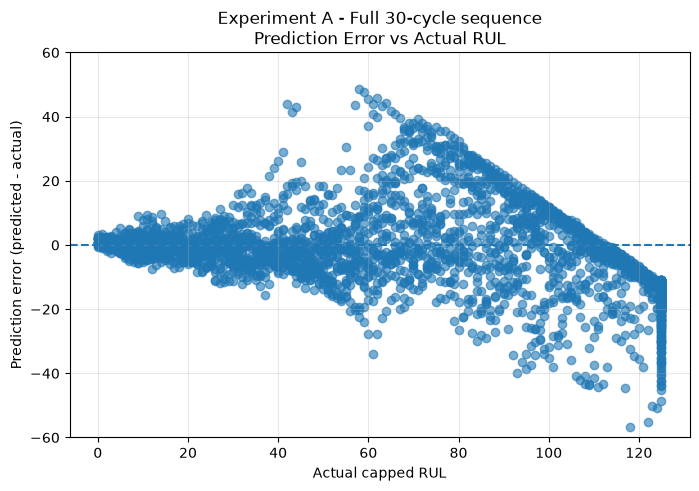

In [15]:
plot_prediction_error(
    y_val_full,
    results_full["predictions"],
    "Experiment A - Full 30-cycle sequence",
)

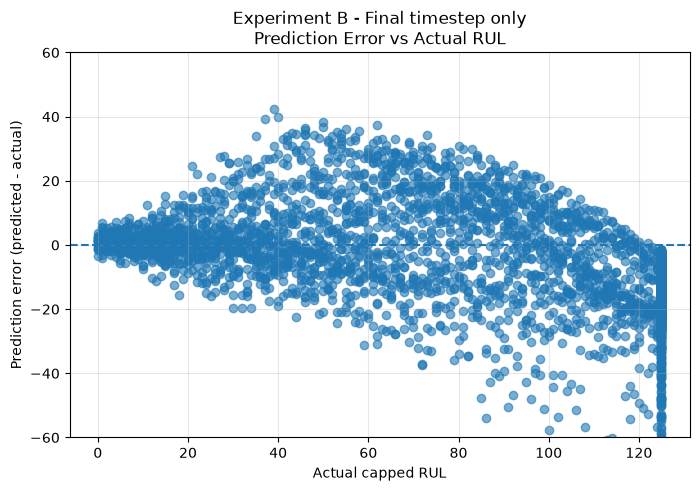

In [16]:
plot_prediction_error(
    y_val_full,
    results_last["predictions"],
    "Experiment B - Final timestep only",
)

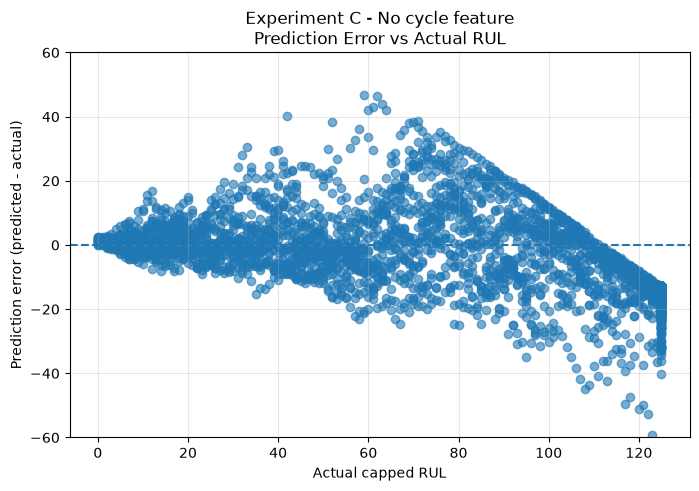

In [17]:
plot_prediction_error(
    y_val_no_cycle,
    results_no_cycle["predictions"],
    "Experiment C - No cycle feature",
)

In [18]:
X_train_full_scaled.shape

(14241, 30, 18)

### Is the overall 30 cycle level enough 

In [19]:
# ============================================================
# Experiment D: Mean feature vector repeated across 30 timesteps
# ============================================================

# Compute the mean of each feature over the 30-cycle window.
# Shape changes:
# (samples, 30, features)
# ->
# (samples, 1, features)
X_train_mean_vector = X_train_full_scaled.mean(
    axis=1,
    keepdims=True,
)

X_val_mean_vector = X_val_full_scaled.mean(
    axis=1,
    keepdims=True,
)

# Repeat the same mean vector across all 30 timesteps.
# Final shape returns to:
# (samples, 30, features)
X_train_mean_repeated = np.repeat(
    X_train_mean_vector,
    repeats=WINDOW,
    axis=1,
)

X_val_mean_repeated = np.repeat(
    X_val_mean_vector,
    repeats=WINDOW,
    axis=1,
)

print("Experiment D: Mean vector repeated")
print("X_train:", X_train_mean_repeated.shape)
print("X_val:", X_val_mean_repeated.shape)


# Create loaders.
(
    train_loader_mean,
    val_loader_mean,
    X_val_mean_tensor,
    y_val_mean_tensor,
) = create_loaders(
    X_train_mean_repeated,
    y_train_full,
    X_val_mean_repeated,
    y_val_full,
    batch_size=64,
)


# Fresh model.
model_mean = RULPredictor(
    input_size=X_train_mean_repeated.shape[2],
    hidden_size=64,
    num_layers=1,
)


# Train.
(
    model_mean,
    history_mean,
    best_epoch_mean,
    best_val_loss_mean,
) = train_model(
    model_mean,
    train_loader_mean,
    val_loader_mean,
    epochs=30,
    learning_rate=0.001,
    overprediction_weight=2.0,
)


# Evaluate.
results_mean = evaluate_model(
    model_mean,
    X_val_mean_tensor,
    y_val_full,
)


print()
print("Experiment D: Mean vector repeated")
print(f"Best epoch: {best_epoch_mean}")

print(
    f"Experiment D - Mean vector repeated - "
    f"Validation MAE: {results_mean['mae']:.2f}"
)

print(
    f"Experiment D - Mean vector repeated - "
    f"Validation MSE: {results_mean['mse']:.2f}"
)

print(
    f"Experiment D - Mean vector repeated - "
    f"Validation RMSE: {results_mean['rmse']:.2f}"
)

Experiment D: Mean vector repeated
X_train: (14241, 30, 18)
X_val: (3490, 30, 18)
Epoch 01 | Train Loss: 6692.47 | Val Loss: 5397.67
Epoch 02 | Train Loss: 4718.05 | Val Loss: 3911.72
Epoch 03 | Train Loss: 3445.05 | Val Loss: 2871.80
Epoch 04 | Train Loss: 2543.93 | Val Loss: 2119.38
Epoch 05 | Train Loss: 1904.55 | Val Loss: 1601.50
Epoch 06 | Train Loss: 1457.87 | Val Loss: 1233.74
Epoch 07 | Train Loss: 1142.22 | Val Loss: 1005.43
Epoch 08 | Train Loss: 933.84 | Val Loss: 819.61
Epoch 09 | Train Loss: 790.42 | Val Loss: 737.78
Epoch 10 | Train Loss: 677.33 | Val Loss: 758.26
Epoch 11 | Train Loss: 609.47 | Val Loss: 636.96
Epoch 12 | Train Loss: 565.04 | Val Loss: 569.97
Epoch 13 | Train Loss: 494.46 | Val Loss: 532.11
Epoch 14 | Train Loss: 453.43 | Val Loss: 548.15
Epoch 15 | Train Loss: 412.43 | Val Loss: 567.99
Epoch 16 | Train Loss: 376.19 | Val Loss: 520.79
Epoch 17 | Train Loss: 344.91 | Val Loss: 543.56
Epoch 18 | Train Loss: 318.38 | Val Loss: 562.85
Epoch 19 | Train Loss:

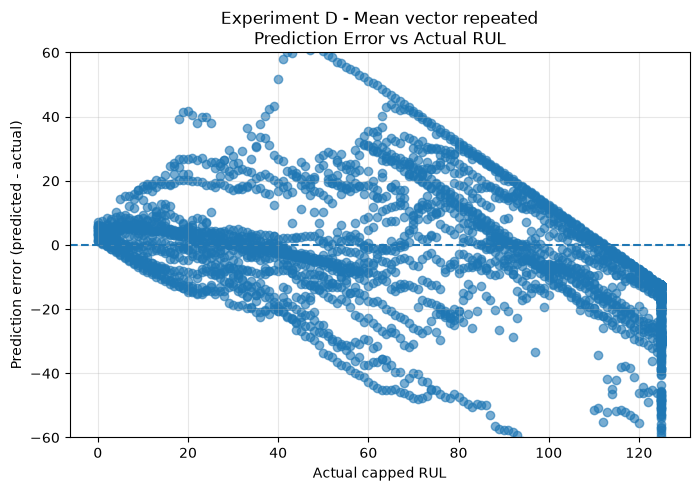

In [20]:
plot_prediction_error(
    y_val_full,
    results_mean["predictions"],
    "Experiment D - Mean vector repeated",
)

### Is the model learning the correct direction of flow of damages? Does the chronology matters

In [23]:
# ============================================================
# Experiment E: Reverse validation timesteps only
# ============================================================

X_val_reversed = X_val_full_scaled[:, ::-1, :].copy()

X_val_reversed_tensor = torch.tensor(
    X_val_reversed,
    dtype=torch.float32,
)

results_reversed = evaluate_model(
    model_full,                 # use the already-trained normal model
    X_val_reversed_tensor,
    y_val_full,
)

print()
print("Experiment E: Reverse validation timesteps only")

print(
    f"Experiment E - Reversed validation sequence - "
    f"Validation MAE: {results_reversed['mae']:.2f}"
)

print(
    f"Experiment E - Reversed validation sequence - "
    f"Validation MSE: {results_reversed['mse']:.2f}"
)

print(
    f"Experiment E - Reversed validation sequence - "
    f"Validation RMSE: {results_reversed['rmse']:.2f}"
)


Experiment E: Reverse validation timesteps only
Experiment E - Reversed validation sequence - Validation MAE: 27.83
Experiment E - Reversed validation sequence - Validation MSE: 1215.62
Experiment E - Reversed validation sequence - Validation RMSE: 34.87


##### When we reverse BOTH train and val set, then the model can simply learn the reversed sequence. So we only reversed the validation set to find out that the real chronology matters

Otherwise the results were impressive when reversed both(equivalent to the non reversed full LSTM)

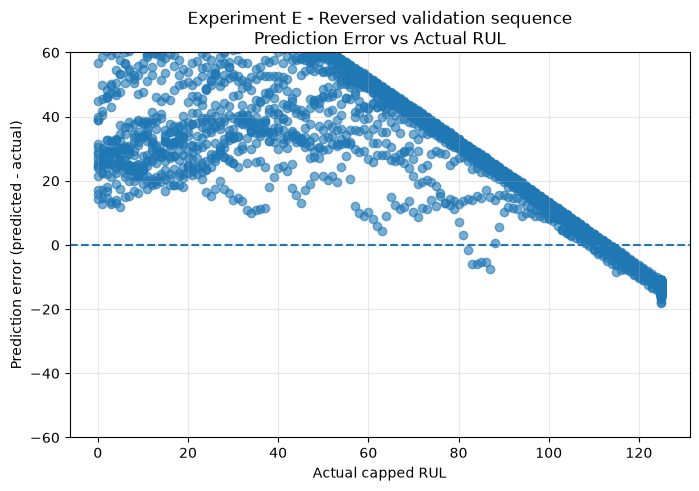

In [24]:
plot_prediction_error(
    y_val_full,
    results_reversed["predictions"],
    "Experiment E - Reversed validation sequence",
)

### Shuffling timesteps withing each validation sequence

In [25]:
# ============================================================
# Experiment F: Shuffle validation timesteps only
# ============================================================

rng = np.random.default_rng(SEED)

X_val_shuffled = X_val_full_scaled.copy()

for i in range(len(X_val_shuffled)):
    permutation = rng.permutation(WINDOW)
    X_val_shuffled[i] = X_val_shuffled[i, permutation, :]

X_val_shuffled_tensor = torch.tensor(
    X_val_shuffled,
    dtype=torch.float32,
)

results_shuffled = evaluate_model(
    model_full,
    X_val_shuffled_tensor,
    y_val_full,
)

print()
print("Experiment F: Shuffle validation timesteps only")

print(
    f"Experiment F - Shuffled validation sequence - "
    f"Validation MAE: {results_shuffled['mae']:.2f}"
)

print(
    f"Experiment F - Shuffled validation sequence - "
    f"Validation MSE: {results_shuffled['mse']:.2f}"
)

print(
    f"Experiment F - Shuffled validation sequence - "
    f"Validation RMSE: {results_shuffled['rmse']:.2f}"
)


Experiment F: Shuffle validation timesteps only
Experiment F - Shuffled validation sequence - Validation MAE: 20.12
Experiment F - Shuffled validation sequence - Validation MSE: 648.28
Experiment F - Shuffled validation sequence - Validation RMSE: 25.46


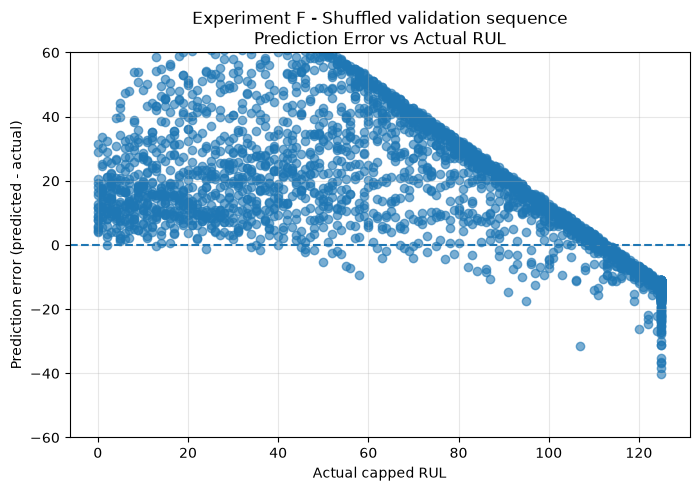

In [26]:
plot_prediction_error(
    y_val_full,
    results_shuffled["predictions"],
    "Experiment F - Shuffled validation sequence",
)

It performed badly which is a "good news" for us, as it definitely is learnign from the changing temporal features 

##### Conclusions till now:
1. Model "doesn't" exploit cycle number or statis sensor levels
2. It's performance depends strongly on the temporal ordering 

## Chcking that if the model is mainly relying on "shortcut" sensors

In [27]:
# ============================================================
# Sensor shortcut analysis: correlation ranking
# ============================================================

candidate_features = [
    col
    for col in sequence_feature_columns
    if col != "cycle"
]

correlations = (
    train_df[candidate_features + ["rul_capped"]]
    .corr()["rul_capped"]
    .drop("rul_capped")
    .sort_values(
        key=lambda s: s.abs(),
        ascending=False,
    )
)

print("Features ranked by absolute correlation with capped RUL:")
print(correlations)

Features ranked by absolute correlation with capped RUL:
sensor_11   -0.771182
sensor_4    -0.752307
sensor_12    0.742395
sensor_7     0.727489
sensor_15   -0.716662
sensor_21    0.703713
sensor_20    0.702987
sensor_17   -0.677277
sensor_2    -0.675215
sensor_3    -0.652131
sensor_8    -0.618789
sensor_13   -0.617328
sensor_9    -0.460180
sensor_14   -0.371959
sensor_6    -0.103699
setting_1   -0.008153
setting_2   -0.002261
Name: rul_capped, dtype: float64


In [28]:
TOP_K = 3

top_correlated_features = (
    correlations
    .head(TOP_K)
    .index
    .tolist()
)

print()
print("Top correlated features:")
print(top_correlated_features)


Top correlated features:
['sensor_11', 'sensor_4', 'sensor_12']


In [30]:
# ============================================================
# Experiment G: Top correlated features only
# ============================================================

X_train_top, y_train_top = create_sequences(
    train_df,
    feature_columns=top_correlated_features,
    target_column="rul_capped",
    window=WINDOW,
)

X_val_top, y_val_top = create_sequences(
    val_df,
    feature_columns=top_correlated_features,
    target_column="rul_capped",
    window=WINDOW,
)

(
    X_train_top_scaled,
    X_val_top_scaled,
    top_scaler,
) = scale_sequences(
    X_train_top,
    X_val_top,
)

(
    train_loader_top,
    val_loader_top,
    X_val_top_tensor,
    y_val_top_tensor,
) = create_loaders(
    X_train_top_scaled,
    y_train_top,
    X_val_top_scaled,
    y_val_top,
    batch_size=64,
)

model_top = RULPredictor(
    input_size=X_train_top_scaled.shape[2],
    hidden_size=64,
    num_layers=1,
)

(
    model_top,
    history_top,
    best_epoch_top,
    best_val_loss_top,
) = train_model(
    model_top,
    train_loader_top,
    val_loader_top,
    epochs=50,
    learning_rate=0.001,
    overprediction_weight=2.0,
)

results_top = evaluate_model(
    model_top,
    X_val_top_tensor,
    y_val_top,
)

print()
print("Experiment G: Top correlated features only")
print(f"Best epoch: {best_epoch_top}")

print(
    f"Experiment G - Top correlated features only - "
    f"Validation MAE: {results_top['mae']:.2f}"
)

print(
    f"Experiment G - Top correlated features only - "
    f"Validation MSE: {results_top['mse']:.2f}"
)

print(
    f"Experiment G - Top correlated features only - "
    f"Validation RMSE: {results_top['rmse']:.2f}"
)

Epoch 01 | Train Loss: 6727.66 | Val Loss: 5457.29
Epoch 02 | Train Loss: 4816.67 | Val Loss: 4037.78
Epoch 03 | Train Loss: 3497.14 | Val Loss: 2879.22
Epoch 04 | Train Loss: 2547.88 | Val Loss: 2104.36
Epoch 05 | Train Loss: 1889.20 | Val Loss: 1554.92
Epoch 06 | Train Loss: 1414.03 | Val Loss: 1172.07
Epoch 07 | Train Loss: 1067.73 | Val Loss: 902.73
Epoch 08 | Train Loss: 846.86 | Val Loss: 696.78
Epoch 09 | Train Loss: 690.60 | Val Loss: 579.36
Epoch 10 | Train Loss: 597.09 | Val Loss: 577.19
Epoch 11 | Train Loss: 540.95 | Val Loss: 443.34
Epoch 12 | Train Loss: 491.46 | Val Loss: 428.15
Epoch 13 | Train Loss: 463.01 | Val Loss: 402.94
Epoch 14 | Train Loss: 445.63 | Val Loss: 384.71
Epoch 15 | Train Loss: 431.61 | Val Loss: 384.72
Epoch 16 | Train Loss: 427.26 | Val Loss: 376.13
Epoch 17 | Train Loss: 413.33 | Val Loss: 355.59
Epoch 18 | Train Loss: 412.24 | Val Loss: 356.78
Epoch 19 | Train Loss: 403.67 | Val Loss: 346.92
Epoch 20 | Train Loss: 397.61 | Val Loss: 347.18
Epoch 2

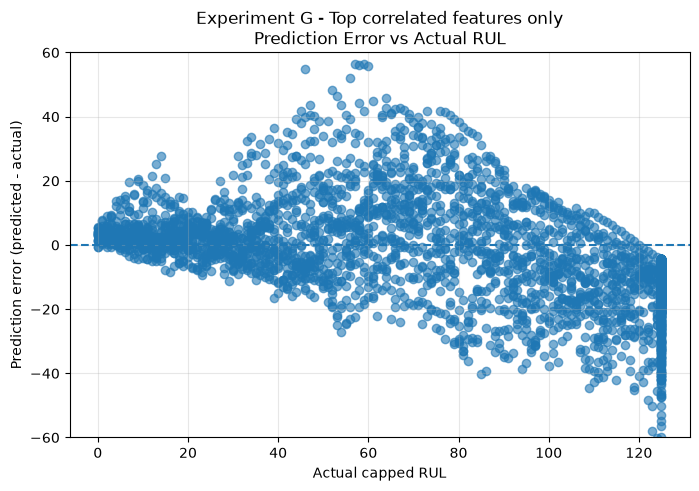

In [31]:
plot_prediction_error(
    y_val_top,
    results_top["predictions"],
    "Experiment G - Top correlated features only",
)

##### This shows top 3 features are fairly predictive but clearly not enough to match the full model, SLTM still benifits from other sensor's reading

#### Now trying to remove top correlated featueres and observing how the model responds

In [32]:
# ============================================================
# Experiment H: Remove top correlated features
# ============================================================

remaining_features = [
    col
    for col in sequence_feature_columns
    if col not in top_correlated_features
]

print("Experiment H: Remove top correlated features")
print("Removed features:", top_correlated_features)
print("Remaining feature count:", len(remaining_features))


# Create sequences.
X_train_without_top, y_train_without_top = create_sequences(
    train_df,
    feature_columns=remaining_features,
    target_column="rul_capped",
    window=WINDOW,
)

X_val_without_top, y_val_without_top = create_sequences(
    val_df,
    feature_columns=remaining_features,
    target_column="rul_capped",
    window=WINDOW,
)


# Scale.
(
    X_train_without_top_scaled,
    X_val_without_top_scaled,
    without_top_scaler,
) = scale_sequences(
    X_train_without_top,
    X_val_without_top,
)


# Loaders.
(
    train_loader_without_top,
    val_loader_without_top,
    X_val_without_top_tensor,
    y_val_without_top_tensor,
) = create_loaders(
    X_train_without_top_scaled,
    y_train_without_top,
    X_val_without_top_scaled,
    y_val_without_top,
    batch_size=64,
)


# Fresh model.
model_without_top = RULPredictor(
    input_size=X_train_without_top_scaled.shape[2],
    hidden_size=64,
    num_layers=1,
)


# Train.
(
    model_without_top,
    history_without_top,
    best_epoch_without_top,
    best_val_loss_without_top,
) = train_model(
    model_without_top,
    train_loader_without_top,
    val_loader_without_top,
    epochs=30,
    learning_rate=0.001,
    overprediction_weight=2.0,
)


# Evaluate.
results_without_top = evaluate_model(
    model_without_top,
    X_val_without_top_tensor,
    y_val_without_top,
)


print()
print("Experiment H: Remove top correlated features")
print(f"Best epoch: {best_epoch_without_top}")

print(
    f"Experiment H - Remove top correlated features - "
    f"Validation MAE: {results_without_top['mae']:.2f}"
)

print(
    f"Experiment H - Remove top correlated features - "
    f"Validation MSE: {results_without_top['mse']:.2f}"
)

print(
    f"Experiment H - Remove top correlated features - "
    f"Validation RMSE: {results_without_top['rmse']:.2f}"
)

Experiment H: Remove top correlated features
Removed features: ['sensor_11', 'sensor_4', 'sensor_12']
Remaining feature count: 15
Epoch 01 | Train Loss: 6771.26 | Val Loss: 5493.15
Epoch 02 | Train Loss: 4792.62 | Val Loss: 3972.65
Epoch 03 | Train Loss: 3475.38 | Val Loss: 2872.30
Epoch 04 | Train Loss: 2513.72 | Val Loss: 2076.51
Epoch 05 | Train Loss: 1829.19 | Val Loss: 1510.91
Epoch 06 | Train Loss: 1341.31 | Val Loss: 1120.23
Epoch 07 | Train Loss: 990.03 | Val Loss: 824.96
Epoch 08 | Train Loss: 740.53 | Val Loss: 635.01
Epoch 09 | Train Loss: 571.15 | Val Loss: 487.70
Epoch 10 | Train Loss: 444.14 | Val Loss: 412.74
Epoch 11 | Train Loss: 352.07 | Val Loss: 349.13
Epoch 12 | Train Loss: 287.54 | Val Loss: 284.40
Epoch 13 | Train Loss: 236.45 | Val Loss: 284.95
Epoch 14 | Train Loss: 202.50 | Val Loss: 288.38
Epoch 15 | Train Loss: 169.84 | Val Loss: 264.80
Epoch 16 | Train Loss: 150.62 | Val Loss: 274.67
Epoch 17 | Train Loss: 137.13 | Val Loss: 296.06
Epoch 18 | Train Loss: 12

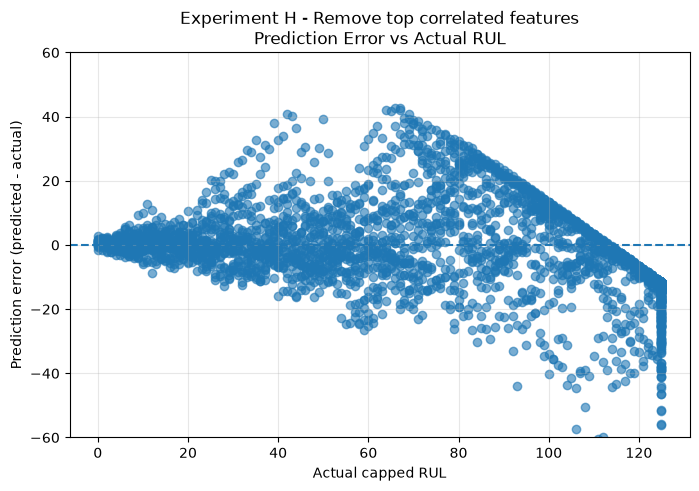

In [33]:
plot_prediction_error(
    y_val_without_top,
    results_without_top["predictions"],
    "Experiment H - Remove top correlated features",
)

Model still has plenty degradation-related signal left even after removing top 3 most correlated features